# Optional 5: Proton Synchrotron Booster in Xsuite
--- 

In [1]:
# Import xsuite modules and other libraries
import xtrack as xt
import xpart as xp
import xplt

import numpy as np
import matplotlib.pyplot as plt

import nafflib
from scipy.signal import argrelextrema
from scipy.fftpack import fft

/home/tprebiba/miniforge3/envs/fcc-2025/lib/python3.12/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)


## The CERN Proton Synchrotron Booster (PSB)

- PSB consists of 4 identical, vertically stacked rings with commin injection and extraction lines. 

- It accelerates protons from $160$ MeV to $2$ GeV in $1.2$ seconds for high-intensity and high-brightness physics. 

- Beam intensities rage from $10^{10}$ to $10^{13}$ protons per ring and the beam emittances from $1$ mm mrad to $15$ mm mrad.

### 📝 Exercise 5a: load and plot the layout of the PSB

Load the PSB line to Xsuite from the MAD-X sequence and plot it using xplt.

In [2]:
# Sequences for all CERN accelerators can be found at: https://gitlab.cern.ch/acc-models
line = xt.Line.from_json('psb_line_thick.json')

Loading line from dict:   0%|          | 0/828 [00:00<?, ?it/s]

Done loading line from dict.           


In [3]:
line_table = line.get_table()
line_table.rows[0:20].cols['name', 's', 'element_type', 'isthick']

LineTable: 20 rows, 4 cols
name                          s element_type     isthick
psb1$start                    0 Marker             False
p01ring1$start                0 Marker             False
drift_0                       0 Drift               True
bi1.bsw1l1.1_aper        0.1795 LimitRectEllipse   False
bi1.bsw1l1.1             0.1795 RBend               True
drift_1                  0.4925 Drift               True
bi1.bsw1l1.2_aper        0.8695 LimitRectEllipse   False
bi1.bsw1l1.2             0.8695 RBend               True
drift_2                  1.1945 Drift               True
bi1.btv1l1              1.32763 Drift               True
drift_3                 1.32763 Drift               True
bi1.bcsf1l1               1.334 Drift               True
bi1.tstr1l1               1.334 Drift               True
drift_4                   1.334 Drift               True
bi1.bsw1l1.3_aper        1.3975 LimitRectEllipse   False
bi1.bsw1l1.3             1.3975 RBend               True
drif

In [4]:
# Get circumference
print('PSB circumference in meters: ', line.get_length()) 

PSB circumference in meters:  157.07999999999979


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


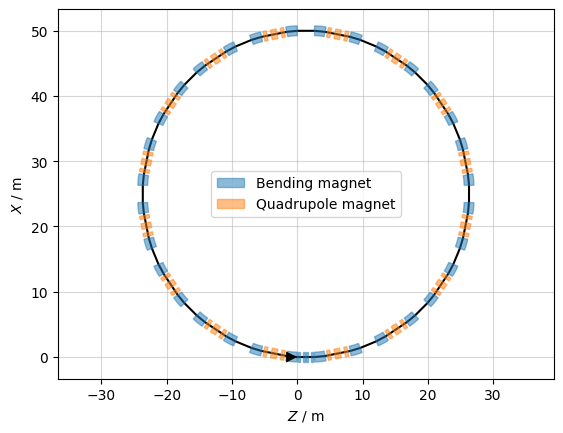

In [5]:
sv = line.survey()
sv.plot()

- The PSB ring consists of 16 identical cells with a total circumference of $157.08$ meters (relatively similar with the cases we have seen so far).

- Each cell (or period or sector) consists of one defocusing and two focusing quadrupoles, two dipoles and many higher order magnets (sextupoles, octupoles, etc). 

### 📝 Exercise 5b: optics functions of PSB

Use the line.twiss() method of Xsuite to compute the optics functions around the PSB and plot them.

In [6]:
# The line should have a reference particle defined, but if not, we can add it as follows:
#line.particle_ref=xp.Particles(mass0=xp.PROTON_MASS_EV,gamma0=1.17)
particle_ref = line.particle_ref
print('Reference particle added at gamma0=%s.'%(particle_ref.gamma0[0]))

# Xsuite tracks in 3D, so we need to add a voltage to the RF cavity to simulate the longitudinal motion
line.element_refs['br.c02'].voltage = 0.008*1e6
print('Constant voltage = 8 kV added to the dummy RF.')

Reference particle added at gamma0=1.1705262269290748.
Constant voltage = 8 kV added to the dummy RF.


In [7]:
#line.twiss_default['method'] = '4d' # to ignore the longitudinal plane
twiss = line.twiss()
print(twiss.keys())

dict_keys(['name', 's', 'x', 'px', 'y', 'py', 'zeta', 'delta', 'ptau', 'W_matrix', 'kin_px', 'kin_py', 'kin_ps', 'kin_xp', 'kin_yp', 'kin_xprime', 'kin_yprime', 'env_name', 'betx', 'bety', 'alfx', 'alfy', 'gamx', 'gamy', 'dx', 'dpx', 'dy', 'dpy', 'dx_zeta', 'dpx_zeta', 'dy_zeta', 'dpy_zeta', 'betx1', 'bety1', 'betx2', 'bety2', 'alfx1', 'alfy1', 'alfx2', 'alfy2', 'gamx1', 'gamy1', 'gamx2', 'gamy2', 'mux', 'muy', 'muzeta', 'nux', 'nuy', 'nuzeta', 'phix', 'phiy', 'phizeta', 'periodic', 'only_markers', 'particle_on_co', 'line_length', 'circumference', '_orientation', 'R_matrix', 'steps_R_matrix', 'steps_r_matrix', 'R_matrix_ebe', 'bets0', 'T_rev0', 't_rev0', 'gamma0', 'beta0', 'p0c', 'slip_factor', 'momentum_compaction_factor', 'slip_factor_dz_ddelta', 'slip_factor_dzeta_ddelta', 'qx', 'qy', 'qs', 'c_minus', 'c_minus_re_0', 'c_minus_im_0', 'c_minus_local', 'c_minus_re', 'c_minus_im', 'c_r1', 'c_r2', 'c_phi1', 'c_phi2', 'eigenvalues', 'rotation_matrix', 'dmux', 'dmuy', 'dzeta', 'bx_chrom', 

In [8]:
twiss.rows[0:10].cols['name s betx bety alfx alfy dx dy']

TwissTable: 10 rows, 8 cols
name                          s          betx          bety          alfx          alfy ...
psb1$start                    0       6.07089       4.04709      0.230494      0.373095
p01ring1$start                0       6.07089       4.04709      0.230494      0.373095
drift_0                       0       6.07089       4.04709      0.230494      0.373095
bi1.bsw1l1.1_aper        0.1795       5.99373       3.92222      0.199356      0.322568
bi1.bsw1l1.1             0.1795       5.99373       3.92222      0.199356      0.322568
drift_1                  0.4925       5.88593       3.74787      0.145059      0.234463
bi1.bsw1l1.2_aper        0.8695       5.80121       3.61109     0.0796605      0.128343
bi1.bsw1l1.2             0.8695       5.80121       3.61109     0.0796605      0.128343
drift_2                  1.1945       5.76775        3.5574     0.0232822     0.0368596
bi1.btv1l1              1.32763       5.76463       3.55258   0.000188261  -0.000614048

In [9]:
twiss_df = twiss.to_pandas() # can be transformed to pandas dataframe for easier manipulation

In [10]:
# This is the twiss table
twiss_df[['s', 'betx', 'alfx', 'gamx', 'mux', 'dx', 'bety', 'alfy', 'gamy', 'muy', 'dy']]

,s,betx,alfx,gamx,mux,dx,bety,alfy,gamy,muy,dy
0,0.000000,6.070889,0.230494,0.173472,0.000000,-1.490317,4.047092,0.373095,0.281486,0.000000,4.058317e-26
1,0.000000,6.070889,0.230494,0.173472,0.000000,-1.490317,4.047092,0.373095,0.281486,0.000000,4.058317e-26
2,0.000000,6.070889,0.230494,0.173472,0.000000,-1.490317,4.047092,0.373095,0.281486,0.000000,4.058317e-26
3,0.179500,5.993731,0.199356,0.173472,0.004737,-1.490307,3.922220,0.322568,0.281486,0.007173,3.941682e-26
4,0.179500,5.993731,0.199356,0.173472,0.004737,-1.490307,3.922220,0.322568,0.281486,0.007173,3.941682e-26
...,...,...,...,...,...,...,...,...,...,...,...
824,155.462304,7.260007,0.509319,0.173472,4.111081,-1.648713,5.820283,0.702765,0.256668,4.595917,4.937693e-26
825,155.462304,7.260007,0.509319,0.173472,4.111081,-1.648713,5.820283,0.702765,0.256668,4.595917,4.937693e-26
826,157.080000,6.070889,0.230494,0.173472,4.150000,-1.490317,4.047092,0.373095,0.281486,4.650000,4.058317e-26
827,157.080000,6.070889,0.230494,0.173472,4.150000,-1.490317,4.047092,0.373095,0.281486,4.650000,4.058317e-26


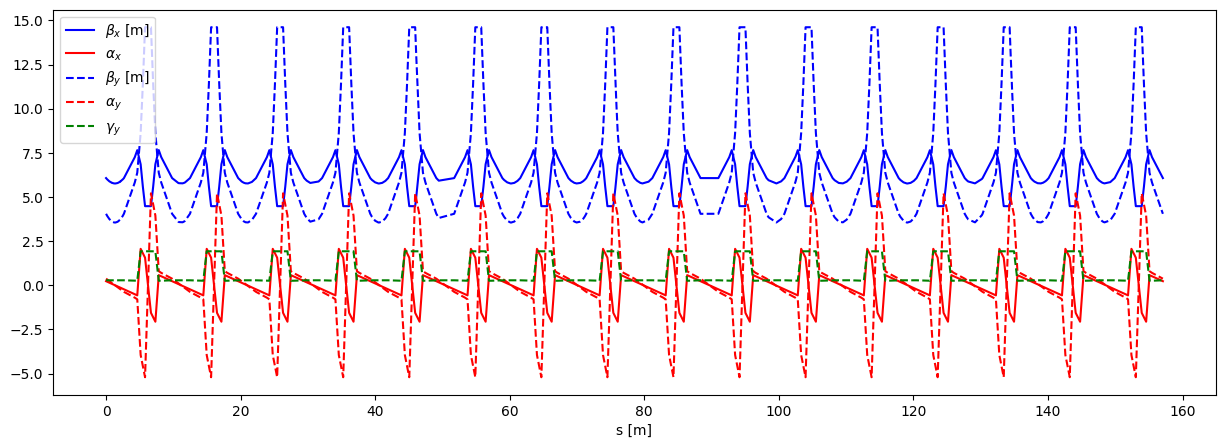

In [11]:
plt.figure(figsize=(15,5))
plt.plot(twiss_df['s'], twiss_df['betx'], label=r'$\beta_x$ [m]', c='blue')
plt.plot(twiss_df['s'], twiss_df['alfx'], label=r'$\alpha_x$', c='red')
plt.plot(twiss_df['s'], twiss_df['bety'], label=r'$\beta_y$ [m]', c='blue', ls='--')
plt.plot(twiss_df['s'], twiss_df['alfy'], label=r'$\alpha_y$', c='red', ls='--')
plt.plot(twiss_df['s'], twiss_df['gamy'], label=r'$\gamma_y$', c='green', ls='--')
plt.xlabel('s [m]')
plt.legend()

### 📝 Exercise 5c: matching the tunes

In PSB, all the focusing quadrupoles are powered in series which means all of them can have the same strength. Same applies for the defocusing quadrupoles. The strength of the focusing quadrupoles is conventionally named as "kbrqf" while for the defocusing "kbrqd". 

Xsuite has algorithms to calculate the quadrupole strengths in order to achieve our desired optics constrains (for example a certain tune, an upper limit for the beta-function etc.). This process is known as optics matching. 

In this exercise, vary the quadrupole strength to match the transverse betatron tunes to $(Q_x,Q_y)=(4.17,4.23)$ using the `line.match` command of Xsuite. 

In [12]:
# The initial lattice gives the following tunes
print('Qx = ', twiss.qx)
print('Qy = ', twiss.qy)

Qx =  4.149999999210823
Qy =  4.649999999620685


In [13]:
# Here we vary the strength of the quadrupoles (two knobs) to reach the target tunes (two constraints)
# The matching process is not always possible..
line.match(
      vary=[
            xt.Vary('kbrqf', step=1e-8),
            xt.Vary('kbrqd', step=1e-8),
      ],
      targets = [
                  xt.Target('qx', 4.17, tol=1e-5),
                  xt.Target('qy', 4.23, tol=1e-5)
      ]
)

                                             
Optimize - start penalty: 4.205                             
Matching: model call n. 11 penalty = 6.4270e-05              
Optimize - end penalty:  6.427e-05                            


In [14]:
# We re-twiss the latice
twiss_after = line.twiss()
twiss_after_df = twiss_after.to_pandas()
print('Horizontal tune after the matching Qx = ', twiss_after.qx)
print('Vertical tune after the matching Qy = ', twiss_after.qy)

Horizontal tune after the matching Qx =  4.169997046134767
Vertical tune after the matching Qy =  4.230005707981085


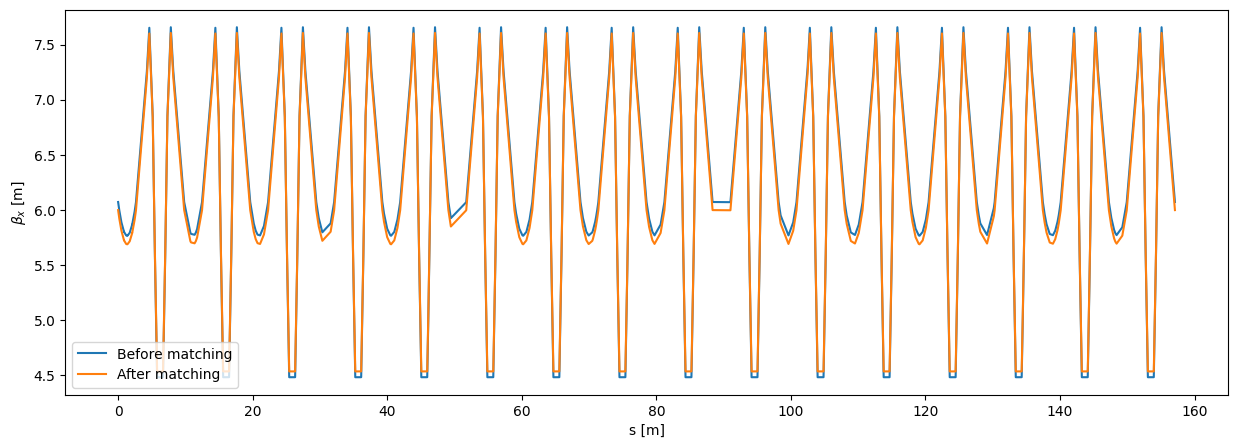

In [15]:
# The beta-function changed in the new configuration of the quadrupoles
plt.figure(figsize=(15,5))
plt.plot(twiss_df['s'], twiss_df['betx'], label='Before matching')
plt.plot(twiss_after_df['s'], twiss_after_df['betx'], label='After matching')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_x$ [m]')
plt.legend()

### 📝 Exercise 5d: tracking in the PSB

- Generate a matched Guassian distribution of $1000$ particles and track it for one turn in the PSB lattice. Plot the particle trajectories along the ring in the vertical plane (y). 

- Track the same distribution for $1000$ turns (without saving the particle state at all PSB elements). How long did it take?


In [16]:
particles = xp.generate_matched_gaussian_bunch(num_particles=1000,
                                total_intensity_particles=1e10,
                                nemitt_x=1e-6, nemitt_y=1e-6, sigma_z=10,
                                particle_ref=line.particle_ref,
                                line=line
                                )

*** Maximum RMS bunch length 24.692096598476198m.


/home/tprebiba/miniforge3/envs/fcc-2025/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


... distance to target bunch length: -1.0000e+01
... distance to target bunch length: 1.4070e+01
... distance to target bunch length: 1.0280e+01
... distance to target bunch length: 7.1279e-01
... distance to target bunch length: -6.6033e-02
... distance to target bunch length: -6.8977e-04
... distance to target bunch length: 1.3118e-08
... distance to target bunch length: -5.5007e-05
--> Bunch length: 10.000000013117544
--> Emittance: 0.23228240107643724


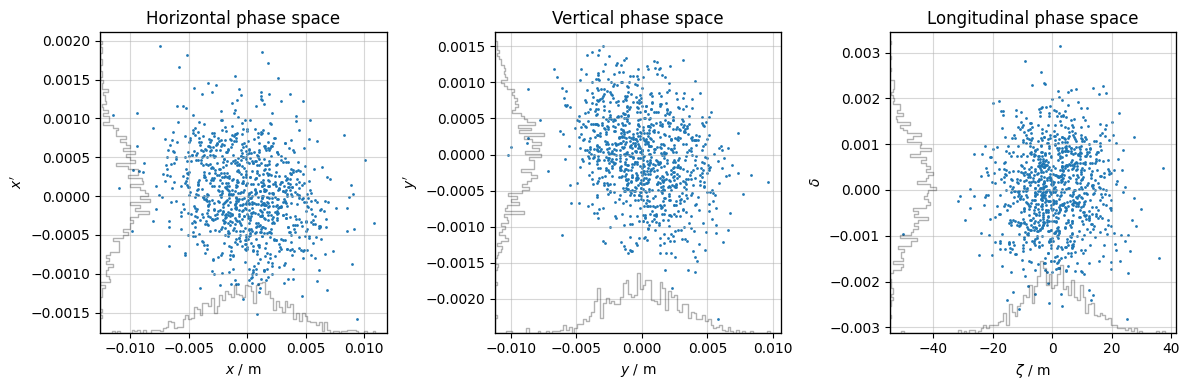

In [17]:
plot = xplt.PhaseSpacePlot(particles)
plot.fig.tight_layout()

In [18]:
# Tracking for one turn but saving the particle distribution at all PSB elements
line.track(particles, num_turns=1, turn_by_turn_monitor='ONE_TURN_EBE') # to save in all elements

Text(0, 0.5, 'y [mm]')

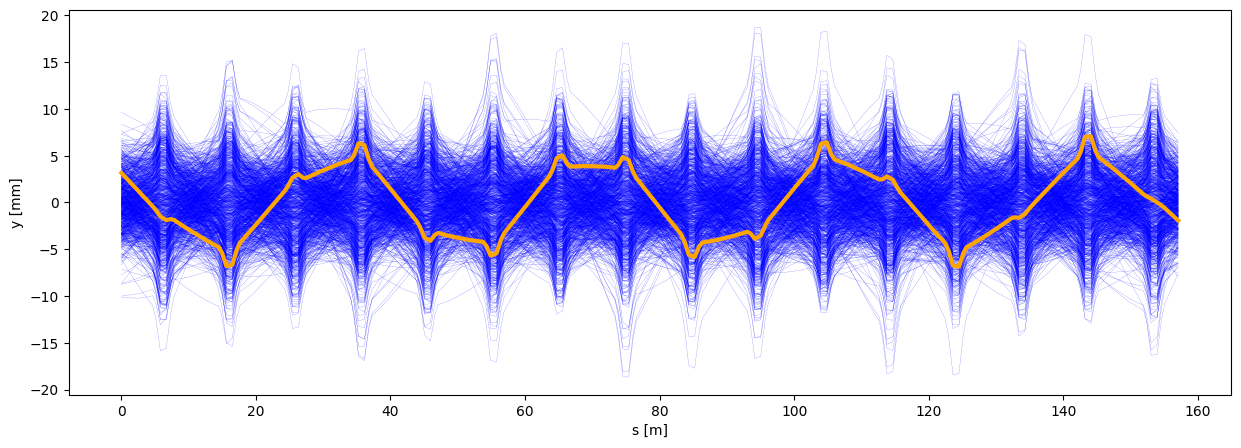

In [19]:
# Plotting the particle trajectories in y
plt.figure(figsize=(15,5))
for i in range(1000):
    plt.plot(line.record_last_track.s[0], line.record_last_track.y[i]*1e3, '-', lw=0.1, c='blue')
plt.plot(line.record_last_track.s[0], line.record_last_track.y[0]*1e3, '-', lw=3, c='orange', label='Single particle trajectory')
plt.xlabel('s [m]')
plt.ylabel('y [mm]')

In [ ]:
import time
start = time.time()
line.track(particles, num_turns=100)
end = time.time()
print('Tracking time for 1000 turns = ', end-start, ' seconds')
print('Tracking time per turn per particle = ', (end-start)/(1000*1000)*1e6, 'microseconds')

### 📝 Exercise 5e: reconstruct tune from turn-by-turn data

- Match the PSB lattice to the working point of $(Q_x, Q_y)=(4.403, 4.453)$  and track a single particle for 800 turns. 

- Do an FFT analysis to calculate the tune from the turn-by-turn data (you can use scipy.fft or NAFFlib)

- Add some noise to the TbT beam position and re-do the FFT.

In [17]:
line = xt.Line.from_json('psb_line_thick.json')
line.element_refs['br.c02'].voltage = 0.008*1e6

Loading line from dict:   0%|          | 0/828 [00:00<?, ?it/s]

Done loading line from dict.           


In [18]:
Qx0 = 4.403
Qy0 = 4.453
# Here we vary the strength of the quadrupoles (two knobs) to reach the target tunes (two constraints)
# The matching process is not always possible..
line.match(
      vary=[
            xt.Vary('kbrqf', step=1e-8),
            xt.Vary('kbrqd', step=1e-8),
      ],
      targets = [
                  xt.Target('qx', Qx0, tol=1e-5),
                  xt.Target('qy', Qy0, tol=1e-5)
      ]
)

twiss = line.twiss()
twiss_df = twiss.to_pandas()

                                             
Optimize - start penalty: 3.207                             
Matching: model call n. 11 penalty = 1.8657e-05              
Optimize - end penalty:  1.86567e-05                            


In [19]:
 # single particle at x=0.5 mm, y=1 mm
particles = line.build_particles(x = [0.5e-3], y=[1e-3])

In [20]:
num_turns = 800
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)

x_tbt = line.record_last_track.x[0]
y_tbt = line.record_last_track.y[0]

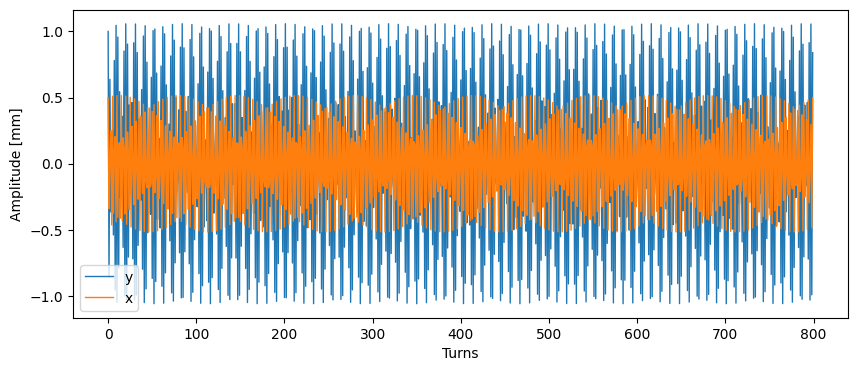

In [21]:
# Plotting turn-by-turn data for the two planes
plt.figure(figsize=(10,4))
plt.plot(y_tbt*1e3, linewidth=1, label='y')
plt.plot(x_tbt*1e3, linewidth=1, label='x')
plt.xlabel('Turns')
plt.ylabel('Amplitude [mm]')
plt.legend()

In [22]:
# spectrum using scipy
data = np.array(y_tbt) # focusing only in the y-plane
N = len(data)
freqs = np.linspace(0,1,N)
ampls = fft(data)
tunes = freqs[:N//2]
norm_ampls = abs(ampls[:N//2])/np.max(abs(ampls))
maximas = argrelextrema(norm_ampls, np.greater)
inds = norm_ampls[maximas].argsort()
max_ampls = norm_ampls[maximas][inds][::-1]
max_tunes = tunes[maximas][inds][::-1]

# spectrum using NAFFlib
norder = 3 # number of the most dominant frequencies
qs, A, B = nafflib.get_tunes(data, norder)

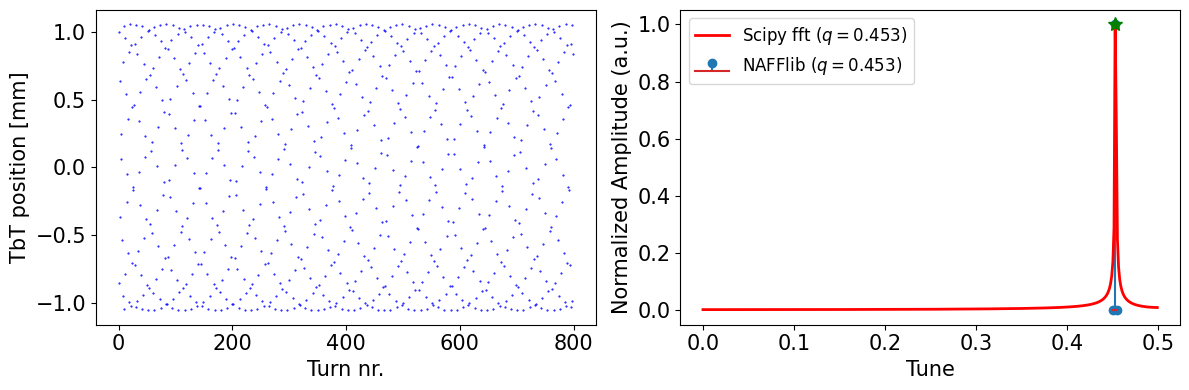

In [23]:
f,axs = plt.subplots(1,2,figsize=(12,4))
fontsize=15

ax = axs[0]
ax.set_xlabel('Turn nr.', fontsize=fontsize)
ax.set_ylabel('TbT position [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(data*1e3, '.', ms=1.0, c='blue')

ax = axs[1]
ax.set_xlabel('Tune', fontsize=fontsize)
ax.set_ylabel('Normalized Amplitude (a.u.)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.stem(qs, abs(A/np.max(A)), label='NAFFlib ($q=%1.3f$)'%qs[0])
ax.plot(tunes, norm_ampls, '-', c='red', lw=2.0, label='Scipy fft ($q=%1.3f$)'%max_tunes[0])
ax.plot(max_tunes[0:1], max_ampls[0:1], '*', ms=10, color='green')
ax.legend(loc=0, fontsize=fontsize-3)
#ax.set_xlim(0.4,0.5)

f.tight_layout()
plt.show()

In [24]:
# Adding errors in the turn-by-turn data
data2 = data + 1e-3*np.random.randn(len(data)) # to simulate noise
#data2 = 1.05*data2 # 5 percent calibration error

# spectrum using scipy
N = len(data2)
freqs = np.linspace(0,1,N)
ampls = fft(data2)
tunes = freqs[:N//2]
norm_ampls = abs(ampls[:N//2])/np.max(abs(ampls))
maximas = argrelextrema(norm_ampls, np.greater)
inds = norm_ampls[maximas].argsort()
max_ampls = norm_ampls[maximas][inds][::-1]
max_tunes = tunes[maximas][inds][::-1]

# spectrum using NAFFlib
norder = 3 # number of the most dominant frequencies
qs, A, B = nafflib.get_tunes(data2, norder)

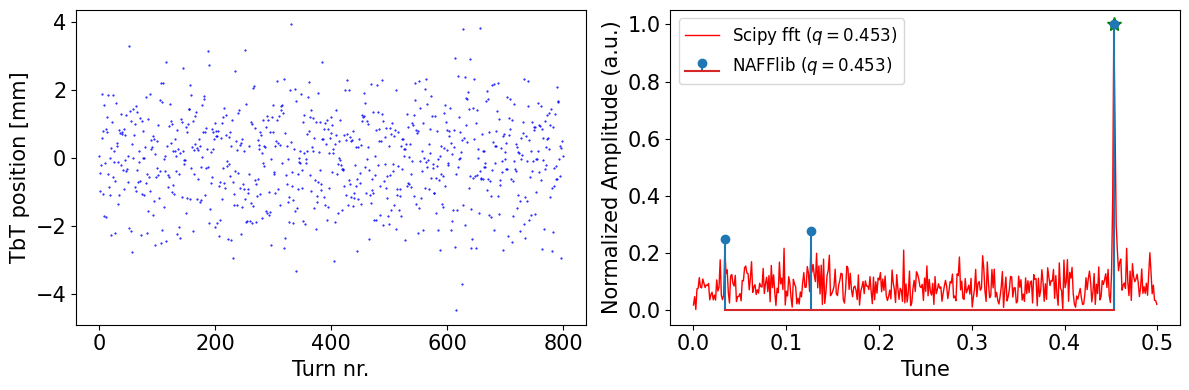

In [25]:
f,axs = plt.subplots(1,2,figsize=(12,4))
fontsize=15

ax = axs[0]
ax.set_xlabel('Turn nr.', fontsize=fontsize)
ax.set_ylabel('TbT position [mm]', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(data2*1e3, '.', ms=1.0, c='blue')

ax = axs[1]
ax.set_xlabel('Tune', fontsize=fontsize)
ax.set_ylabel('Normalized Amplitude (a.u.)', fontsize=fontsize)
ax.tick_params(labelsize=fontsize)
ax.plot(tunes, norm_ampls, '-', c='red', lw=1.0, label='Scipy fft ($q=%1.3f$)'%max_tunes[0])
ax.plot(max_tunes[0:1], max_ampls[0:1], '*', ms=10, color='green')
ax.stem(qs, abs(A/np.max(A)), label='NAFFlib ($q=%1.3f$)'%qs[0])
ax.legend(loc=0, fontsize=fontsize-3)
#ax.set_xlim(0.4,0.5)

f.tight_layout()
plt.show()


### 📝 Exercise 5f: motion near a quadrupolar resonance - beta-beating

- Match the PSB lattice to the working point of $(Q_x, Q_y)=(4.403, 4.473)$ and save the twiss table.

- Add a quadrupole error (impoerfection) in the lattice. You can do that by power the QNO816 quadrupoles with an integrated strength of 0.0045 (line variable name "kbr1qno816l3").

- Re-twiss and compare the vertical beta functino ('bety') with the initial twiss table. What do you observe?

- Generate a matched Guassian distribution of $1000$ particles and track it for one turn in the PSB lattice. Plot the particle trajectories along the ring in the vertical plane (y). What do you observe?

In [26]:
# Loading and matching the PSB lattice
line = xt.Line.from_json('psb_line_thick.json')
line.element_refs['br.c02'].voltage = 0.008*1e6
Qx0 = 4.403
Qy0 = 4.490
line.match(vary=[xt.Vary('kbrqf', step=1e-8),xt.Vary('kbrqd', step=1e-8)],
           targets = [xt.Target('qx', Qx0, tol=1e-5),xt.Target('qy', Qy0, tol=1e-5)])
twiss = line.twiss()
twiss_before = twiss.to_pandas()

Loading line from dict:   0%|          | 0/828 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 2.993                             
Matching: model call n. 11 penalty = 6.2932e-05              
Optimize - end penalty:  6.29315e-05                            


In [27]:
# Assigning the quadrupolar error to the lattice
line.vars['kbr1qno816l3'] = 0.0045

In [28]:
# Re-twissing after the error
twiss = line.twiss()
twiss_after = twiss.to_pandas()

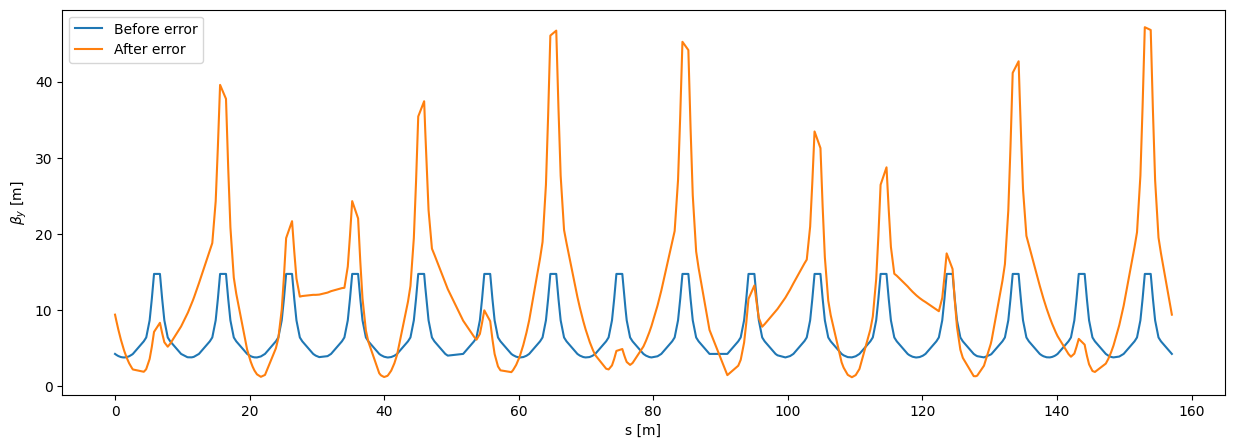

In [29]:
# Plotting the beta functions before and after the error
plt.figure(figsize=(15,5))
plt.plot(twiss_before['s'], twiss_before['bety'], label='Before error')
plt.plot(twiss_after['s'], twiss_after['bety'], label='After error')
plt.xlabel('s [m]')
plt.ylabel(r'$\beta_y$ [m]')
plt.legend()

> Note: the quadrupolar error perturbed the vertical beta-function. This effect is known as beta-beating and is particularly enhanced when the tune is near a half-integer value (here Qy=4.49 close to 4.5).

In [39]:
# generate matched distribution
particles = xp.generate_matched_gaussian_bunch(num_particles=1000,
                                total_intensity_particles=1e10,
                                nemitt_x=1e-6, nemitt_y=1e-6, sigma_z=10,
                                particle_ref=line.particle_ref,
                                line=line
                                )

*** Maximum RMS bunch length 24.69209659847621m.


/home/tprebiba/miniforge3/envs/fcc-2025/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


... distance to target bunch length: -1.0000e+01
... distance to target bunch length: 1.4070e+01
... distance to target bunch length: 1.0280e+01
... distance to target bunch length: 7.1279e-01
... distance to target bunch length: -6.6033e-02
... distance to target bunch length: -6.8977e-04
... distance to target bunch length: 1.3118e-08
... distance to target bunch length: -5.5007e-05
--> Bunch length: 10.000000013117543
--> Emittance: 0.23119205385810257


In [106]:
# Tracking for one turn but saving the particle distribution at all PSB elements
line.track(particles, num_turns=1, turn_by_turn_monitor='ONE_TURN_EBE') # to save in all elements

Text(0, 0.5, 'y [mm]')

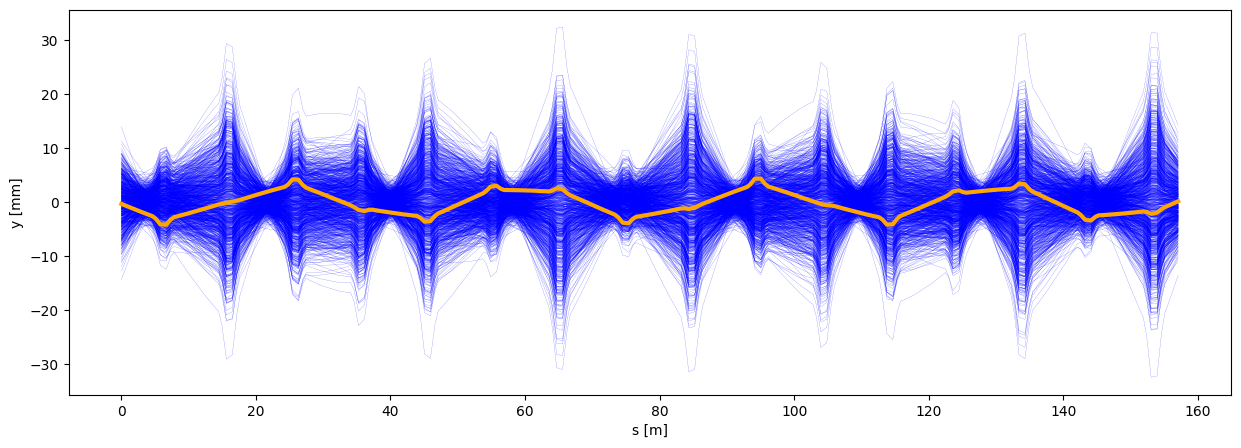

In [107]:
# Plotting the particle trajectories in y
plt.figure(figsize=(15,5))
for i in range(1000):
    plt.plot(line.record_last_track.s[0], line.record_last_track.y[i]*1e3, '-', lw=0.1, c='blue')
plt.plot(line.record_last_track.s[0], line.record_last_track.y[0]*1e3, '-', lw=3, c='orange', label='Single particle trajectory')
plt.xlabel('s [m]')
plt.ylabel('y [mm]')

> Note how perturbed is the motion of the particles in the y-plane after the quadrupolar error. 

### 📝 Exercise 5g: motion on a quadrupolar resonance - phase space

- From the previous example, track a single particle for 800 turns and plot the vertical phase space (**phase space near a resonance**).

- Re-match the lattice at $(Q_x, Q_y)=(4.23, 4.17)$, re-track for 800 turns and plot the same phase space (**phase space far from a resonance**). 

- Re-match the lattice at $(Q_x, Q_y)=(4.40, 4.495)$, re-track for 800 turns and plot the same phase space (**phase space on a resonance**). 

In [30]:
# Rematching the tunes to (Qx,Qy) = (4.403,4.49)
line.vars['kbr1qno816l3'] = 0.0
line.match(vary=[xt.Vary('kbrqf', step=1e-8),xt.Vary('kbrqd', step=1e-8)],
           targets = [xt.Target('qx', 4.403, tol=1e-5), xt.Target('qy', 4.49, tol=1e-5)])
line.vars['kbr1qno816l3'] = 0.0045
particles = line.build_particles(x = [0.5e-3], y=[1e-3]) # single particle at x=0.5 mm, y=1 mm
num_turns = 800
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)
y_tbt = line.record_last_track.y[0]
py_tbt = line.record_last_track.py[0]

                                             
Optimize - start penalty: 6.293e-05                         
Matching: model call n. 2 penalty = 6.2932e-05              
Optimize - end penalty:  6.29315e-05                            


Text(0, 0.5, 'py [mrad]')

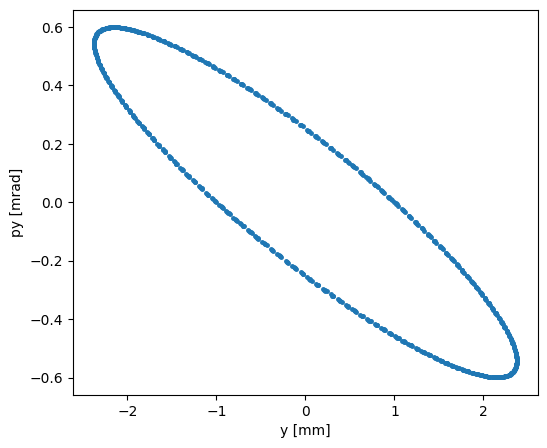

In [31]:
plt.figure(figsize=(6,5))
plt.plot(y_tbt*1e3, py_tbt*1e3, '.', ms=5)
plt.xlabel('y [mm]')
plt.ylabel('py [mrad]')

> Note: phase space near a resonance is stable but perturbed.

In [32]:
# Rematching the tunes to (Qx,Qy) = (4.17,4.23)
line.vars['kbr1qno816l3'] = 0.0
line.match(vary=[xt.Vary('kbrqf', step=1e-8),xt.Vary('kbrqd', step=1e-8)],
           targets = [xt.Target('qx', 4.17, tol=1e-5), xt.Target('qy', 4.23, tol=1e-5)])
line.vars['kbr1qno816l3'] = 0.0045
# Retracking
particles = line.build_particles(x = [0.5e-3], y=[1e-3]) # single particle at x=0.5 mm, y=1 mm
num_turns = 800
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)
y_tbt = line.record_last_track.y[0]
py_tbt = line.record_last_track.py[0]

                                             
Optimize - start penalty: 3.491                             
Matching: model call n. 11 penalty = 6.1860e-05              
Optimize - end penalty:  6.18597e-05                            


Text(0, 0.5, 'py [mrad]')

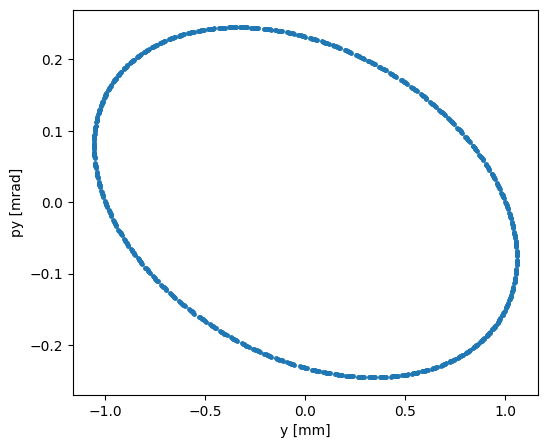

In [33]:
plt.figure(figsize=(6,5))
plt.plot(y_tbt*1e3, py_tbt*1e3, '.', ms=5)
plt.xlabel('y [mm]')
plt.ylabel('py [mrad]')

> Note: phase space far from the resonance is not pertubed.

In [34]:
# Rematching the tunes to (Qx,Qy) = (4.403,4.493)
line.vars['kbr1qno816l3'] = 0.0
line.match(vary=[xt.Vary('kbrqf', step=1e-8),xt.Vary('kbrqd', step=1e-8)],
           targets = [xt.Target('qx', 4.403, tol=1e-5), xt.Target('qy', 4.493, tol=1e-5)])
line.vars['kbr1qno816l3'] = 0.0045
# Retracking
particles = line.build_particles(x = [0.5e-3], y=[1e-3]) # single particle at x=0.5 mm, y=1 mm
num_turns = 800
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)
y_tbt = line.record_last_track.y[0]
py_tbt = line.record_last_track.py[0]

                                             
Optimize - start penalty: 3.514                             
Matching: model call n. 16 penalty = 6.3987e-08              
Optimize - end penalty:  6.39868e-08                            


Text(0, 0.5, 'py [mrad]')

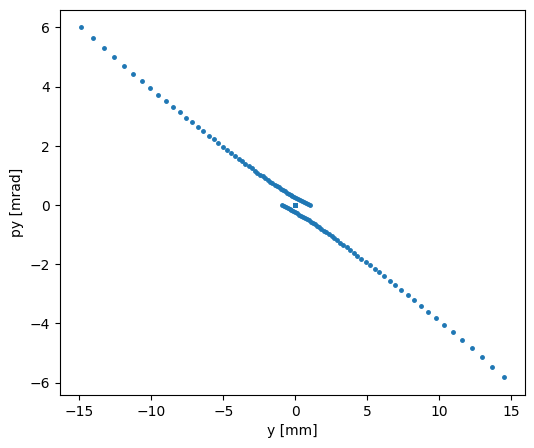

In [35]:
plt.figure(figsize=(6,5))
plt.plot(y_tbt*1e3, py_tbt*1e3, '.', ms=5)
plt.xlabel('y [mm]')
plt.ylabel('py [mrad]')

> Note: the phase space is unstable on the resonance.